In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5

def euler_method(r, A, dt, J):
    inputs = np.dot(A, r)
    return r + dt * (-r + sigmoid(inputs))

def compute_mean_firing_rate(rates):
    return np.mean(rates, axis=1)

def compute_variance_firing_rate(rates):
    return np.var(rates, axis=1)

In [2]:
# parameters
N = 83  # no. of nodes
J = 1.0  # scaling factor
dt = 0.01  # time step
T = 100  # total time
time_steps = int(T / dt)
p = 0.1  # connection probability

In [6]:
# network architectures

# fully connected network (all nodes connected with equal weight)
A_fully_connected = np.ones((N, N)) * J / N

# Erdos-Renyi network (connections are random w.p. p)
k = p * N
A_erdos_renyi = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if np.random.rand() < p:
            A_erdos_renyi[i, j] = J / k

# Gaussian random network (each weight drawn from a Gaussian distribution)
A_gaussian_random = np.random.normal(0, J / math.sqrt(N), size=(N, N))

In [7]:
# initialise rates for all networks
initial_rates = np.random.uniform(0, 1, N)

# firing rate evolution is simulated using the Euler method for each type of network

# simulate dynamics for fully connected network
rates_fully_connected = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_fully_connected[t] = r
    r = euler_method(r, A_fully_connected, dt, J)

mean_firing_rate_fully_connected = compute_mean_firing_rate(rates_fully_connected)
variance_firing_rate_fully_connected = compute_variance_firing_rate(rates_fully_connected)

# simulate dynamics for Erdos-Renyi network
rates_erdos_renyi = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_erdos_renyi[t] = r
    r = euler_method(r, A_erdos_renyi, dt, J)

mean_firing_rate_erdos_renyi = compute_mean_firing_rate(rates_erdos_renyi)
variance_firing_rate_erdos_renyi = compute_variance_firing_rate(rates_erdos_renyi)

# simulate dynamics for Gaussian random network
rates_gaussian_random = np.zeros((time_steps, N))
r = initial_rates.copy()
for t in range(time_steps):
    rates_gaussian_random[t] = r
    r = euler_method(r, A_gaussian_random, dt, J)

mean_firing_rate_gaussian_random = compute_mean_firing_rate(rates_gaussian_random)
variance_firing_rate_gaussian_random = compute_variance_firing_rate(rates_gaussian_random)

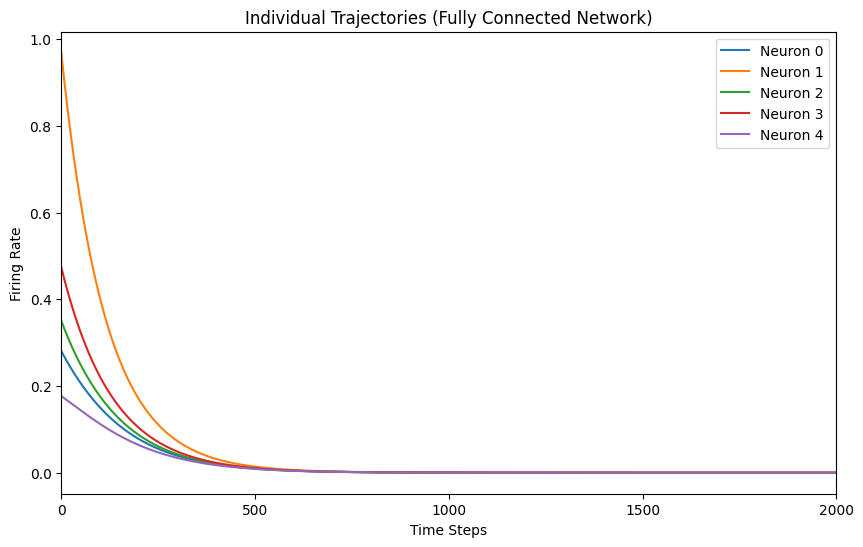

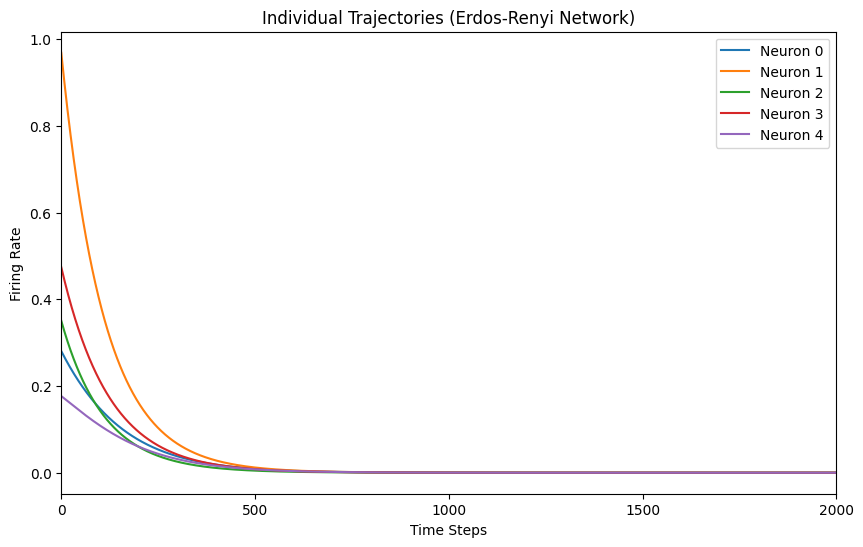

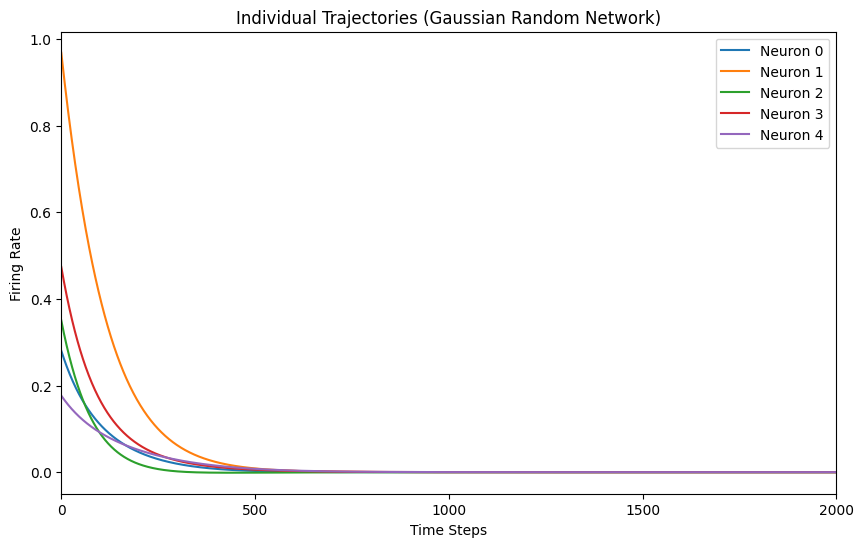

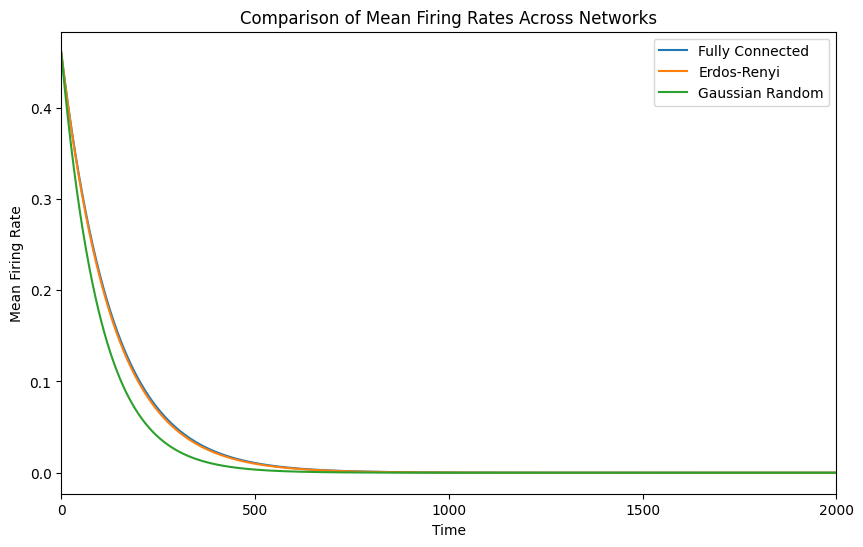

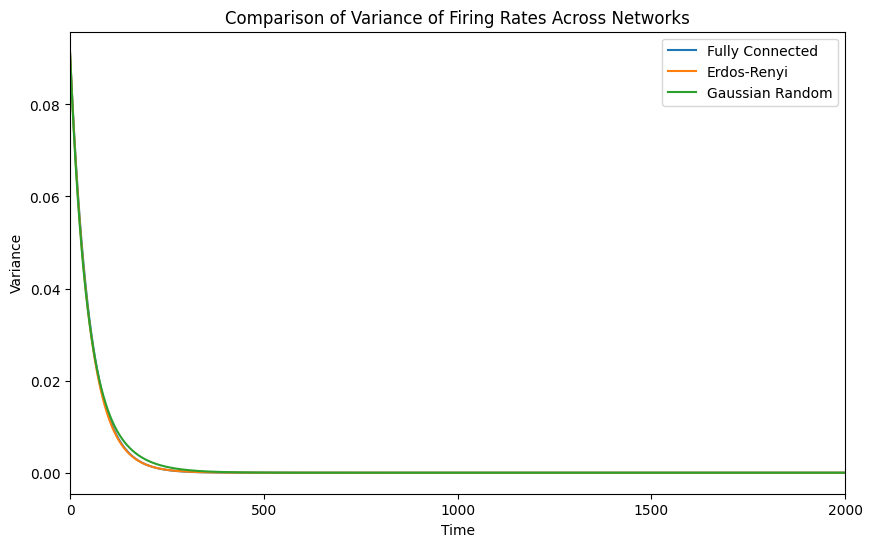

In [8]:
# plot individual trajectories for each network type (firing rate evolution for each neuron over time)
networks = {
    "Fully Connected Network": rates_fully_connected,
    "Erdos-Renyi Network": rates_erdos_renyi,
    "Gaussian Random Network": rates_gaussian_random,
}

for name, rates in networks.items():
    plt.figure(figsize=(10, 6))
    for i in range(min(5, rates.shape[1])):  # labels for first 5 neurons
        plt.plot(rates[:, i], label=f'Neuron {i}')
    plt.title(f'Individual Trajectories ({name})')
    plt.xlabel('Time Steps')
    plt.ylabel('Firing Rate')
    plt.legend()
    plt.xlim(0, 2000)  # limit to 2000 time steps
    plt.xticks(np.arange(0, 2001, 500))
    plt.show()

# compare how different network topologies affect the system's behaviour

# compare mean firing rates across networks
plt.figure(figsize=(10, 6))
plt.plot(mean_firing_rate_fully_connected, label='Fully Connected')
plt.plot(mean_firing_rate_erdos_renyi, label='Erdos-Renyi')
plt.plot(mean_firing_rate_gaussian_random, label='Gaussian Random')
plt.title('Comparison of Mean Firing Rates Across Networks')
plt.xlabel('Time')
plt.ylabel('Mean Firing Rate')
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2001, 500))
plt.legend()
plt.show()

# compare variance of firing rates across networks
plt.figure(figsize=(10, 6))
plt.plot(variance_firing_rate_fully_connected, label='Fully Connected')
plt.plot(variance_firing_rate_erdos_renyi, label='Erdos-Renyi')
plt.plot(variance_firing_rate_gaussian_random, label='Gaussian Random')
plt.title('Comparison of Variance of Firing Rates Across Networks')
plt.xlabel('Time')
plt.ylabel('Variance')
plt.xlim(0, 2000)
plt.xticks(np.arange(0, 2001, 500))
plt.legend()
plt.show()